# Exploratory analysis

## Objective

Identify sample associations between credit outcomes and borrower/loan characteristics using four focused figures and compact supporting tables. This is descriptive EDA; it does not build models, perform SQL analysis, or create a dashboard.

**Target: 0 = Bad; 1 = Good.** `credit_risk_label` is display-only and must never be used as a predictor later. Both target representations must be excluded from future predictors.

**Business questions:** How do account status, repayment history, savings, duration/amount, employment and installment burden relate to outcomes? Do purpose, housing/property and other debtors add useful context? Does the duration pattern persist within checking-status groups?

## Dataset overview

Load the existing cleaned CSV without writing to it. Use the cleaning notebook’s root discovery: search the current directory and parents, or set `CREDIT_RISK_PROJECT_ROOT` when launching outside the checkout.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from statistics import NormalDist
from IPython.display import Markdown
from IPython.display import display


def find_project_root():
    configured_root = os.environ.get("CREDIT_RISK_PROJECT_ROOT")
    candidates = (
        [Path(configured_root).expanduser().resolve()]
        if configured_root
        else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    )
    for candidate in candidates:
        if (candidate / "data/raw/SouthGermanCredit.asc").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the repository. Set CREDIT_RISK_PROJECT_ROOT to its directory."
    )


project_root = find_project_root()
clean_path = project_root / "data/processed/south_german_credit_clean.csv"
df = pd.read_csv(clean_path)
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
BAD_COLOR = "#b45336"
GOOD_COLOR = "#26758a"
SPARSE_THRESHOLD = 30


In [2]:
quantitative = ["duration_months", "credit_amount", "age"]
ordinal = ["employment_duration", "installment_rate", "residence_duration", "property", "number_credits", "job"]
nominal = ["checking_status", "credit_history", "purpose", "savings", "personal_status_sex", "other_debtors", "other_installment_plans", "housing"]
binary = ["people_liable", "telephone", "foreign_worker"]
expected_columns = quantitative + ordinal + nominal + binary + ["credit_risk", "credit_risk_label"]
if set(df.columns) != set(expected_columns) or df.columns.duplicated().any():
    raise ValueError("The cleaned dataset schema is unexpected.")
if df.empty or df.isna().any().any() or not df["credit_risk"].isin([0, 1]).all():
    raise ValueError("Expected nonempty data, no missing values, and a binary target.")
if not df["credit_risk_label"].equals(df["credit_risk"].map({0: "Bad", 1: "Good"})):
    raise ValueError("Display labels do not match the numeric target.")

display(pd.DataFrame({"Records": [len(df)], "Columns": [df.shape[1]], "Missing fields": [df.isna().sum().sum()], "Duplicate rows": [df.duplicated().sum()]}))
display(pd.DataFrame({"Type": ["Quantitative", "Ordinal", "Nominal", "Binary predictors", "Target/display"], "Variables": [", ".join(x) for x in [quantitative, ordinal, nominal, binary, ["credit_risk", "credit_risk_label"]]]}))


,Records,Columns,Missing fields,Duplicate rows
0,1000,22,0,0


,Type,Variables
0,Quantitative,"duration_months, credit_amount, age"
1,Ordinal,"employment_duration, installment_rate, residen..."
2,Nominal,"checking_status, credit_history, purpose, savi..."
3,Binary predictors,"people_liable, telephone, foreign_worker"
4,Target/display,"credit_risk, credit_risk_label"


### Category labels and comparison method

Labels below are transcribed from the corrected UCI archive’s `codetable.txt`, verified against `read_SouthGermanCredit.R`: [dataset and background](https://www.archive.ics.uci.edu/dataset/573/south%2Bgerman%2Bcredit%2Bupdate), [official source archive](https://archive.ics.uci.edu/static/public/573/south+german+credit+update.zip). They are embedded so execution needs no network access. Values in the CSV remain unchanged.

**Bad share** is Bad records divided by all records in a group. Each main comparison shows a **95% Wilson score interval**, calculated with a standard-normal critical value (approximately 1.96), without continuity correction. These are descriptive binomial uncertainty intervals conditional on the sampled records; they do not correct oversampling or support population default-probability claims. No significance tests or multiple-comparison claims are made.

Groups with **n < 30** are marked sparse; this is a review heuristic, not a guarantee that larger groups are reliable. Empty documented categories have undefined shares and intervals.

In [3]:
category_labels = {'checking_status': {1: 'no checking account', 2: '... < 0 DM', 3: '0<= ... < 200 DM', 4: '... >= 200 DM / salary for at least 1 year'}, 'credit_history': {0: 'delay in paying off in the past', 1: 'critical account/other credits elsewhere', 2: 'no credits taken/all credits paid back duly', 3: 'existing credits paid back duly till now', 4: 'all credits at this bank paid back duly'}, 'purpose': {0: 'others', 1: 'car (new)', 2: 'car (used)', 3: 'furniture/equipment', 4: 'radio/television', 5: 'domestic appliances', 6: 'repairs', 7: 'education', 8: 'vacation', 9: 'retraining', 10: 'business'}, 'savings': {1: 'unknown/no savings account', 2: '... <  100 DM', 3: '100 <= ... <  500 DM', 4: '500 <= ... < 1000 DM', 5: '... >= 1000 DM'}, 'employment_duration': {1: 'unemployed', 2: '< 1 yr', 3: '1 <= ... < 4 yrs', 4: '4 <= ... < 7 yrs', 5: '>= 7 yrs'}, 'installment_rate': {1: '>= 35', 2: '25 <= ... < 35', 3: '20 <= ... < 25', 4: '< 20'}, 'other_debtors': {1: 'none', 2: 'co-applicant', 3: 'guarantor'}, 'property': {1: 'unknown / no property', 2: 'car or other', 3: 'building soc. savings agr./life insurance', 4: 'real estate'}, 'housing': {1: 'for free', 2: 'rent', 3: 'own'}}

for variable, mapping in category_labels.items():
    if not df[variable].isin(mapping).all():
        raise ValueError(f"Undocumented category in {variable}.")


def wilson_interval(bad, total):
    if total == 0:
        return float("nan"), float("nan")
    z = NormalDist().inv_cdf(0.975)
    p = bad / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    half_width = z * (p * (1 - p) / total + z**2 / (4 * total**2))**0.5 / denominator
    return max(0, center - half_width), min(1, center + half_width)


def category_summary(variable):
    grouped = df.groupby(variable)["credit_risk"].agg(
        total_records="size", bad_records=lambda s: s.eq(0).sum()
    ).reindex(list(category_labels[variable]), fill_value=0)
    grouped.index.name = "code"
    grouped.insert(0, "category", [category_labels[variable][k] for k in grouped.index])
    grouped["bad_share"] = grouped["bad_records"] / grouped["total_records"].replace(0, float("nan"))
    intervals = [wilson_interval(k, n) for k, n in zip(grouped.bad_records, grouped.total_records)]
    grouped["wilson_low"] = [x[0] for x in intervals]
    grouped["wilson_high"] = [x[1] for x in intervals]
    grouped["support"] = ["empty" if n == 0 else "sparse" if n < SPARSE_THRESHOLD else "" for n in grouped.total_records]
    return grouped


def show_summary(table, intervals=True):
    columns = ["category", "total_records", "bad_records", "bad_share"]
    if intervals:
        columns += ["wilson_low", "wilson_high"]
    columns += ["support"]
    formatting = {name: "{:.1%}" for name in ["bad_share", "wilson_low", "wilson_high"] if name in columns}
    display(table[columns].style.format(formatting, na_rep="—"))


def plot_comparisons(variables, title, figsize):
    fig, axes = plt.subplots(1, len(variables), figsize=figsize, sharex=True, layout="constrained")
    for ax, variable in zip(axes, variables):
        table = summaries[variable]
        valid = table.total_records.gt(0)
        t = table.loc[valid]
        values = t.bad_share.to_numpy() * 100
        errors = [(t.bad_share - t.wilson_low).to_numpy() * 100,
                  (t.wilson_high - t.bad_share).to_numpy() * 100]
        ax.errorbar(values, range(len(t)), xerr=errors, fmt="o", color=BAD_COLOR, capsize=3)
        tick_labels = [f"{label} (n={n}{'*' if n < SPARSE_THRESHOLD else ''})" for label, n in zip(t.category, t.total_records)]
        ax.set_yticks(range(len(t)), tick_labels)
        ax.invert_yaxis()
        ax.axvline(baseline_bad_share * 100, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(0, 100)
        ax.set_xlabel("Bad share (%)")
        ax.set_title(variable.replace("_", " ").title())
        ax.grid(axis="x", alpha=0.2)
    fig.suptitle(title + "\n95% Wilson intervals; dashed line = sample Bad share; * n < 30")
    plt.show()
    plt.close(fig)


## Target distribution

Report counts and percentages with a single bar chart. The 30% Bad share describes this deliberately stratified sample.

,records,percentage
outcome,,
Bad (0),300,30.0%
Good (1),700,70.0%


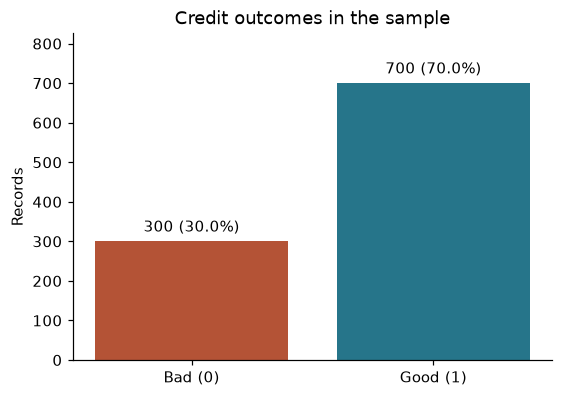

In [4]:
target_distribution = df["credit_risk"].value_counts().reindex([0, 1], fill_value=0).rename("records").to_frame()
target_distribution.index = pd.Index(["Bad (0)", "Good (1)"], name="outcome")
target_distribution["percentage"] = target_distribution.records / len(df) * 100
baseline_bad_share = df.credit_risk.eq(0).mean()
display(target_distribution.style.format({"percentage": "{:.1f}%"}))
fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")
bars = ax.bar(target_distribution.index, target_distribution.records, color=[BAD_COLOR, GOOD_COLOR])
ax.bar_label(bars, labels=[f"{n} ({p:.1f}%)" for n, p in zip(target_distribution.records, target_distribution.percentage)], padding=4)
ax.set(title="Credit outcomes in the sample", ylabel="Records", ylim=(0, target_distribution.records.max() * 1.18))
plt.show()
plt.close(fig)

## Quantitative variables

Compare actual measurements: duration in months, recorded transformed credit amount, and age in years. Report count, median, Q1, Q3 and IQR by outcome. Boxplot whiskers use 1.5 × IQR; points outside them are retained observations, not automatically invalid records.

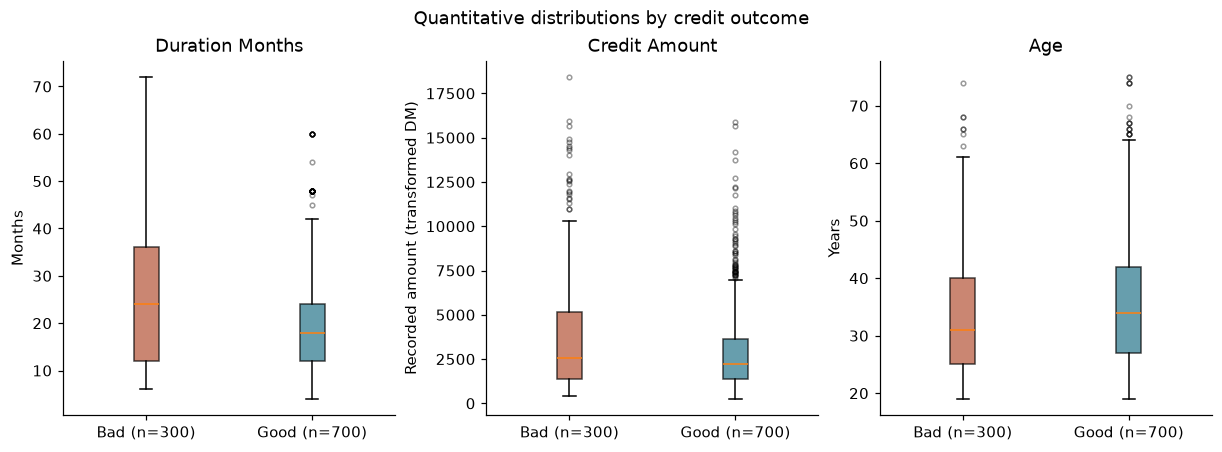

In [5]:
quantitative_summary = pd.concat({
    variable: df.groupby("credit_risk_label")[variable].agg(
        count="count", median="median", Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75)
    ) for variable in quantitative
}, axis=1).reindex(["Bad", "Good"])
for variable in quantitative:
    quantitative_summary[(variable, "IQR")] = quantitative_summary[(variable, "Q3")] - quantitative_summary[(variable, "Q1")]
quantitative_summary = quantitative_summary.reindex(columns=pd.MultiIndex.from_product([quantitative, ["count", "median", "Q1", "Q3", "IQR"]]))
display(quantitative_summary.style.format({(v, metric): ("{:.0f}" if metric == "count" else "{:.1f}") for v in quantitative for metric in ["count", "median", "Q1", "Q3", "IQR"]}))
fig, axes = plt.subplots(1, 3, figsize=(11, 4), layout="constrained")
units = ["Months", "Recorded amount (transformed DM)", "Years"]
for ax, variable, unit in zip(axes, quantitative, units):
    result = ax.boxplot([df.loc[df.credit_risk.eq(k), variable] for k in [0, 1]], tick_labels=[f"{label} (n={df.credit_risk.eq(k).sum()})" for k, label in [(0, "Bad"), (1, "Good")]], patch_artist=True, flierprops={"markersize": 3, "alpha": 0.4})
    for box, color in zip(result["boxes"], [BAD_COLOR, GOOD_COLOR]):
        box.set_facecolor(color)
        box.set_alpha(0.7)
    ax.set(title=variable.replace("_", " ").title(), ylabel=unit)
fig.suptitle("Quantitative distributions by credit outcome")
plt.show()
plt.close(fig)

## Financial/account categories

Checking status, credit history, and savings use the corrected code labels. In particular, code 1 means no checking account for checking status, and unknown/no savings account for savings. Compare proportions with denominators rather than only Bad counts. Category labels represent historical DM brackets.

### Checking Status

,category,total_records,bad_records,bad_share,wilson_low,wilson_high,support
code,,,,,,,
1,no checking account,274,135,49.3%,43.4%,55.2%,
2,... < 0 DM,269,105,39.0%,33.4%,45.0%,
3,0<= ... < 200 DM,63,14,22.2%,13.7%,33.9%,
4,... >= 200 DM / salary for at least 1 year,394,46,11.7%,8.9%,15.2%,


### Credit History

,category,total_records,bad_records,bad_share,wilson_low,wilson_high,support
code,,,,,,,
0,delay in paying off in the past,40,25,62.5%,47.0%,75.8%,
1,critical account/other credits elsewhere,49,28,57.1%,43.3%,70.0%,
2,no credits taken/all credits paid back duly,530,169,31.9%,28.1%,36.0%,
3,existing credits paid back duly till now,88,28,31.8%,23.0%,42.1%,
4,all credits at this bank paid back duly,293,50,17.1%,13.2%,21.8%,


### Savings

,category,total_records,bad_records,bad_share,wilson_low,wilson_high,support
code,,,,,,,
1,unknown/no savings account,603,217,36.0%,32.3%,39.9%,
2,... < 100 DM,103,34,33.0%,24.7%,42.6%,
3,100 <= ... < 500 DM,63,11,17.5%,10.0%,28.6%,
4,500 <= ... < 1000 DM,48,6,12.5%,5.9%,24.7%,
5,... >= 1000 DM,183,32,17.5%,12.7%,23.6%,


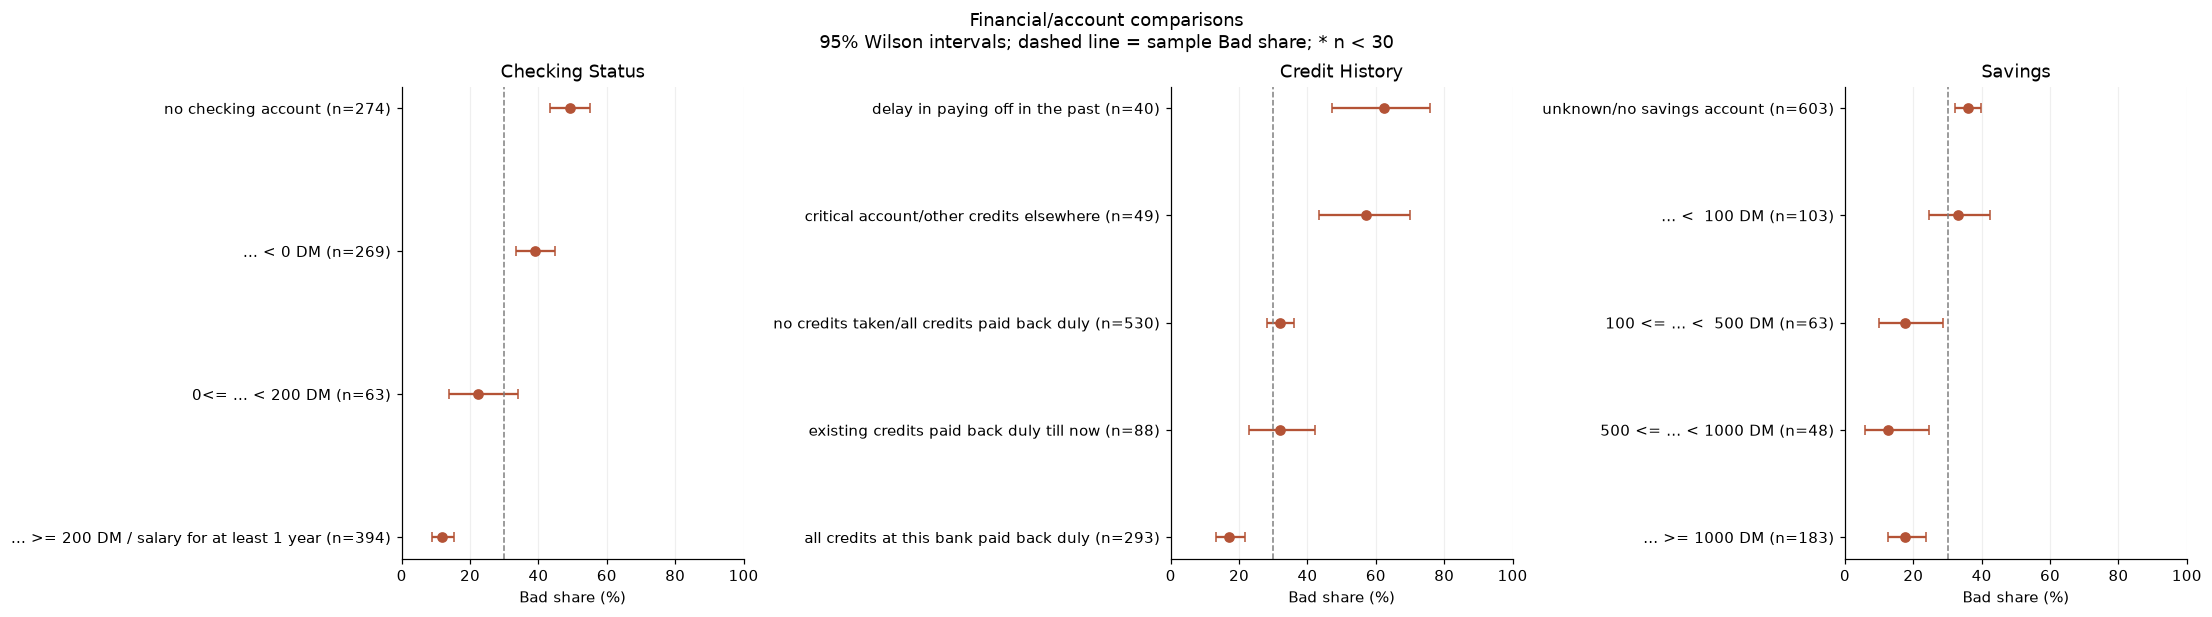

In [6]:
summaries = {variable: category_summary(variable) for variable in category_labels}
financial_variables = ["checking_status", "credit_history", "savings"]
for variable in financial_variables:
    display(Markdown(f"### {variable.replace('_', ' ').title()}"))
    show_summary(summaries[variable])
plot_comparisons(financial_variables, "Financial/account comparisons", (20, 5.5))

## Ordered/ordinal variables

Employment duration follows codes 1–5, from unemployed through the longest employment band. Installment rate follows documented codes 1–4: **≥35%, 25–<35%, 20–<25%, <20%** of disposable income. Thus its displayed burden decreases as the code increases. Codes are categories, not literal percentages or equally spaced measurements.

### Employment Duration

,category,total_records,bad_records,bad_share,wilson_low,wilson_high,support
code,,,,,,,
1,unemployed,62,23,37.1%,26.2%,49.5%,
2,< 1 yr,172,70,40.7%,33.6%,48.2%,
3,1 <= ... < 4 yrs,339,104,30.7%,26.0%,35.8%,
4,4 <= ... < 7 yrs,174,39,22.4%,16.9%,29.2%,
5,>= 7 yrs,253,64,25.3%,20.3%,31.0%,


### Installment Rate

,category,total_records,bad_records,bad_share,wilson_low,wilson_high,support
code,,,,,,,
1,>= 35,136,34,25.0%,18.5%,32.9%,
2,25 <= ... < 35,231,62,26.8%,21.5%,32.9%,
3,20 <= ... < 25,157,45,28.7%,22.2%,36.2%,
4,< 20,476,159,33.4%,29.3%,37.8%,


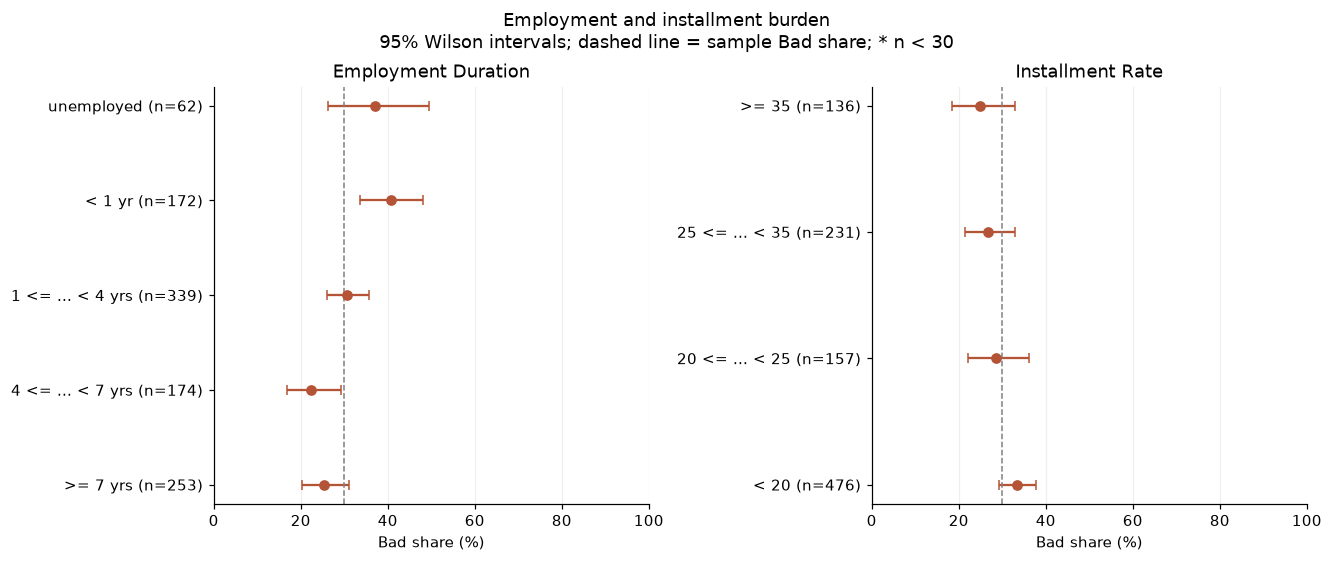

In [7]:
ordered_variables = ["employment_duration", "installment_rate"]
for variable in ordered_variables:
    display(Markdown(f"### {variable.replace('_', ' ').title()}"))
    show_summary(summaries[variable])
plot_comparisons(ordered_variables, "Employment and installment burden", (12, 5))

## Secondary categorical comparisons

Show purpose, housing, property, and other debtors as compact tables. No extra chart is needed. Property is an ordered asset category, but it is summarized categorically here. Housing codes mean 1 = for free, 2 = rent, 3 = own. Keep the documented education category visible even though it has no records; its share is undefined. Read sparse purposes cautiously.

In [8]:
for variable in ["purpose", "housing", "property", "other_debtors"]:
    display(Markdown(f"### {variable.replace('_', ' ').title()}"))
    show_summary(summaries[variable], intervals=False)

### Purpose

,category,total_records,bad_records,bad_share,support
code,,,,,
0,others,234,89,38.0%,
1,car (new),103,17,16.5%,
2,car (used),181,58,32.0%,
3,furniture/equipment,280,62,22.1%,
4,radio/television,12,4,33.3%,sparse
5,domestic appliances,22,8,36.4%,sparse
6,repairs,50,22,44.0%,
7,education,0,0,—,empty
8,vacation,9,1,11.1%,sparse


### Housing

,category,total_records,bad_records,bad_share,support
code,,,,,
1,for free,179,70,39.1%,
2,rent,714,186,26.1%,
3,own,107,44,41.1%,


### Property

,category,total_records,bad_records,bad_share,support
code,,,,,
1,unknown / no property,282,60,21.3%,
2,car or other,232,71,30.6%,
3,building soc. savings agr./life insurance,332,102,30.7%,
4,real estate,154,67,43.5%,


### Other Debtors

,category,total_records,bad_records,bad_share,support
code,,,,,
1,none,907,272,30.0%,
2,co-applicant,41,18,43.9%,
3,guarantor,52,10,19.2%,


## Limited joint analysis

Use preselected duration bands **≤12, >12–24, >24–36, >36 months**. Boundaries are inclusive at 12, 24 and 36; these are reporting choices, not optimized cutoffs. Compare Bad share within each checking-status category. Each cell shows **Bad percentage [Bad count / total count]**. Mark n < 30 as sparse and avoid strong interpretation, especially for n < 10. Use a table instead of a heatmap because support is uneven.

In [9]:
duration_labels = ["≤12 months", ">12–24 months", ">24–36 months", ">36 months"]
duration_band = pd.cut(df.duration_months, bins=[0, 12, 24, 36, float("inf")], labels=duration_labels, right=True)
if duration_band.isna().any():
    raise ValueError("Some durations are outside the reporting bands.")
joint_data = df.assign(duration_band=duration_band)
joint_summary = joint_data.groupby(["checking_status", "duration_band"], observed=False).credit_risk.agg(
    total_records="size", bad_records=lambda s: s.eq(0).sum()
)
joint_summary["bad_share"] = joint_summary.bad_records / joint_summary.total_records.replace(0, float("nan"))
joint_summary["sparse"] = joint_summary.total_records.lt(SPARSE_THRESHOLD)
joint_display = pd.DataFrame(index=list(category_labels["checking_status"].values()), columns=duration_labels)
for (status, band), row in joint_summary.iterrows():
    n, bad = int(row.total_records), int(row.bad_records)
    cell = "— [0/0]" if n == 0 else f"{row.bad_share:.1%} [{bad}/{n}]"
    if n < SPARSE_THRESHOLD:
        cell += " *"
    joint_display.loc[category_labels["checking_status"][status], band] = cell
joint_display.index.name = "Checking status"
if joint_summary.total_records.sum() != len(df):
    raise ValueError("Joint analysis did not preserve all records.")
display(joint_display)
print("* Sparse: n < 30. Brackets show Bad records / total records.")

,≤12 months,>12–24 months,>24–36 months,>36 months
Checking status,,,,
no checking account,35.9% [33/92],50.8% [60/118],57.9% [22/38],76.9% [20/26] *
... < 0 DM,29.7% [27/91],34.7% [34/98],52.3% [23/44],58.3% [21/36]
0<= ... < 200 DM,16.7% [5/30],29.2% [7/24] *,28.6% [2/7] *,0.0% [0/2] *
... >= 200 DM / salary for at least 1 year,7.5% [11/146],12.3% [21/171],18.5% [10/54],17.4% [4/23] *


* Sparse: n < 30. Brackets show Bad records / total records.


## Key findings and limitations

The five findings below are generated from the current data and group summaries, so they update on rerun. They describe associations, not causation, statistical significance, or contemporary default probabilities.

In [10]:
checking = summaries["checking_status"]
history = summaries["credit_history"]
savings = summaries["savings"]
installments = summaries["installment_rate"]

def group_fact(table, code):
    row = table.loc[code]
    return f"{row.bad_share:.1%} Bad ({int(row.bad_records)}/{int(row.total_records)})"

medians = df.groupby("credit_risk_label")[quantitative].median()
findings = [
    f"**Account status:** No checking account: {group_fact(checking, 1)}; the ≥200 DM / salary-for-at-least-one-year category: {group_fact(checking, 4)}. The contrast is substantial in this sample.",
    f"**Recorded repayment history:** Past payment delays: {group_fact(history, 0)}; critical account/other credits elsewhere: {group_fact(history, 1)}; all credits at this bank paid duly: {group_fact(history, 4)}. Category meaning matters more than the numerical code.",
    f"**Savings:** Unknown/no savings account: {group_fact(savings, 1)}; 500–<1,000 DM: {group_fact(savings, 4)}; ≥1,000 DM: {group_fact(savings, 5)}. The recorded brackets do not form a strictly monotonic Bad-share pattern.",
    f"**Loan characteristics:** Bad records (n={int(df.credit_risk.eq(0).sum())}) have median duration {medians.loc['Bad', 'duration_months']:.0f} months and recorded amount {medians.loc['Bad', 'credit_amount']:.1f}; Good records (n={int(df.credit_risk.eq(1).sum())}) have medians {medians.loc['Good', 'duration_months']:.0f} months and {medians.loc['Good', 'credit_amount']:.1f}. Distributions overlap; amounts are transformed historical values.",
    f"**Installment burden:** The ≥35% category has {group_fact(installments, 1)}, versus {group_fact(installments, 4)} in the <20% category. This does not support a simple 'higher burden means more Bad outcomes' account in this unadjusted sample.",
]
display(Markdown("\n\n".join(f"{i}. {finding}" for i, finding in enumerate(findings, 1))))

1. **Account status:** No checking account: 49.3% Bad (135/274); the ≥200 DM / salary-for-at-least-one-year category: 11.7% Bad (46/394). The contrast is substantial in this sample.

2. **Recorded repayment history:** Past payment delays: 62.5% Bad (25/40); critical account/other credits elsewhere: 57.1% Bad (28/49); all credits at this bank paid duly: 17.1% Bad (50/293). Category meaning matters more than the numerical code.

3. **Savings:** Unknown/no savings account: 36.0% Bad (217/603); 500–<1,000 DM: 12.5% Bad (6/48); ≥1,000 DM: 17.5% Bad (32/183). The recorded brackets do not form a strictly monotonic Bad-share pattern.

4. **Loan characteristics:** Bad records (n=300) have median duration 24 months and recorded amount 2574.5; Good records (n=700) have medians 18 months and 2244.0. Distributions overlap; amounts are transformed historical values.

5. **Installment burden:** The ≥35% category has 25.0% Bad (34/136), versus 33.4% Bad (159/476) in the <20% category. This does not support a simple 'higher burden means more Bad outcomes' account in this unadjusted sample.

### Limitations and choices to review

- Records are from **1973–1975** and reflect historical lending conditions.
- **Bad credits were deliberately oversampled.** Category percentages are sample associations, not population default probabilities.
- **Credit amounts were transformed** by an unknown monotonic transformation; do not interpret their numerical differences as actual loan-value differences.
- **`personal_status_sex` cannot be interpreted as recoverable sex.** It is intentionally excluded from demographic conclusions.
- **Sparse groups require caution.** n < 30 flags support, not reliability; small event counts can remain uncertain even in larger groups. Empty categories are not zero-risk groups.
- Wilson intervals describe sampling uncertainty under a binomial working model; they do not account for the stratified design, selection, dependence, or many simultaneous comparisons. Interval overlap/non-overlap is not used as a significance test.
- These are mostly unadjusted comparisons; joint tables provide limited context, not control for confounding or a prediction model. Records represent granted credits, not all loan applicants.
- Review the duration boundaries (12/24/36 months), sparse threshold (30), and historical category interpretations before extending the analysis. No cutoffs were selected to maximize outcome differences.
- Only quantitative columns receive boxplots. Nominal code averages and an all-column correlation heatmap are deliberately excluded.

Sources: [UCI dataset](https://www.archive.ics.uci.edu/dataset/573/south%2Bgerman%2Bcredit%2Bupdate), its corrected code table/R reader linked above, and [Grömping’s dataset background report](https://www1.beuth-hochschule.de/FB_II/reports/Report-2019-004.pdf).